In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/thapar-summer-school-employee-salary-prediction/sample-submission.csv
/kaggle/input/thapar-summer-school-employee-salary-prediction/train.csv
/kaggle/input/thapar-summer-school-employee-salary-prediction/test.csv


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [6]:
test = pd.read_csv('/kaggle/input/thapar-summer-school-employee-salary-prediction/test.csv')
test.head()

,id,company,department,age,age_when_joined,years_in_the_company,annual_bonus,prior_years_experience,full_time,part_time,contractor
0,1,Glasses,Search Engine,45,48,1,9000.00000,4,0.000000,0.160612,1.000000
1,2,Glasses,AI,41,42,1,16938.16716,4,0.470456,0.000000,0.723912
2,3,Cheerper,Search Engine,33,23,9,14608.56178,4,0.339699,0.762610,0.000000
3,4,Pear,Sales,34,29,5,22838.07655,2,0.995955,0.000000,0.409629
4,5,Glasses,BigData,42,41,1,15630.23134,2,0.000000,0.721474,0.593769


In [7]:
train = pd.read_csv('/kaggle/input/thapar-summer-school-employee-salary-prediction/train.csv')
train.head()

,id,company,department,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,full_time,part_time,contractor
0,1,Cheerper,Support,40,36,4,69420.46872,22586.99591,2,0.000000,0.893809,0.328591
1,2,Cheerper,BigData,40,34,6,88407.04974,18676.07837,3,0.205947,0.756632,0.036870
2,3,Pear,Sales,41,39,2,97831.84885,19287.87365,2,0.942309,0.000000,0.514457
3,4,Glasses,Search Engine,39,33,6,93905.86813,17936.39297,3,0.484373,0.236922,0.278535
4,5,Glasses,AI,39,35,3,105983.97520,16854.92943,3,0.835346,0.308958,0.000000


In [8]:
combined = pd.concat([train,test])
combined.head()

,id,company,department,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,full_time,part_time,contractor
0,1,Cheerper,Support,40,36,4,69420.46872,22586.99591,2,0.000000,0.893809,0.328591
1,2,Cheerper,BigData,40,34,6,88407.04974,18676.07837,3,0.205947,0.756632,0.036870
2,3,Pear,Sales,41,39,2,97831.84885,19287.87365,2,0.942309,0.000000,0.514457
3,4,Glasses,Search Engine,39,33,6,93905.86813,17936.39297,3,0.484373,0.236922,0.278535
4,5,Glasses,AI,39,35,3,105983.97520,16854.92943,3,0.835346,0.308958,0.000000


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 150000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      150000 non-null  int64  
 1   company                 150000 non-null  object 
 2   department              150000 non-null  object 
 3   age                     150000 non-null  int64  
 4   age_when_joined         150000 non-null  int64  
 5   years_in_the_company    150000 non-null  int64  
 6   salary                  100000 non-null  float64
 7   annual_bonus            150000 non-null  float64
 8   prior_years_experience  150000 non-null  int64  
 9   full_time               150000 non-null  float64
 10  part_time               150000 non-null  float64
 11  contractor              150000 non-null  float64
dtypes: float64(5), int64(5), object(2)
memory usage: 14.9+ MB


In [7]:
combined.dtypes

id                          int64
company                    object
department                 object
age                         int64
age_when_joined             int64
years_in_the_company        int64
salary                    float64
annual_bonus              float64
prior_years_experience      int64
full_time                 float64
part_time                 float64
contractor                float64
dtype: object

In [8]:
combined.isnull().sum()

id                            0
company                       0
department                    0
age                           0
age_when_joined               0
years_in_the_company          0
salary                    50000
annual_bonus                  0
prior_years_experience        0
full_time                     0
part_time                     0
contractor                    0
dtype: int64

In [9]:
combined.shape

(150000, 12)

In [10]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,150000.0,41667.166667,27638.632047,1.0,18750.750000,37500.500000,62500.250000,100000.00
age,150000.0,38.223020,6.014709,30.0,33.000000,38.000000,43.000000,49.00
age_when_joined,150000.0,33.567447,7.722324,22.0,27.000000,33.000000,39.000000,48.00
years_in_the_company,150000.0,4.662367,2.531471,1.0,3.000000,5.000000,7.000000,9.00
salary,100000.0,87389.018245,28478.542805,40000.0,66027.961360,86554.204990,107269.920325,153000.00
annual_bonus,150000.0,18571.436417,4378.495948,9000.0,15435.698605,18813.149745,22164.901467,24792.91
prior_years_experience,150000.0,2.504340,1.207594,1.0,1.000000,2.000000,3.000000,5.00
full_time,150000.0,0.383592,0.340530,0.0,0.016012,0.333338,0.654228,1.00
part_time,150000.0,0.383062,0.339761,0.0,0.015585,0.334144,0.650425,1.00
contractor,150000.0,0.382673,0.339780,0.0,0.014480,0.332248,0.650586,1.00


In [11]:
combined.kurt()

/tmp/ipykernel_33/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


id                       -0.882634
age                      -1.075162
age_when_joined          -0.957810
years_in_the_company     -1.080288
salary                   -0.632011
annual_bonus             -0.779422
prior_years_experience   -0.806878
full_time                -1.123521
part_time                -1.117211
contractor               -1.115797
dtype: float64

In [12]:
combined.skew()

/tmp/ipykernel_33/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


id                        0.438566
age                       0.224584
age_when_joined           0.169993
years_in_the_company      0.134977
salary                    0.201022
annual_bonus             -0.308661
prior_years_experience    0.379503
full_time                 0.428710
part_time                 0.428857
contractor                0.431393
dtype: float64

In [13]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

/tmp/ipykernel_33/2240195514.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)


id                        43749.500000
age                          10.000000
age_when_joined              12.000000
years_in_the_company          4.000000
salary                    41241.958965
annual_bonus               6729.202863
prior_years_experience        2.000000
full_time                     0.638215
part_time                     0.634839
contractor                    0.636106
dtype: float64


/tmp/ipykernel_33/2240195514.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)
/tmp/ipykernel_33/2240195514.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [14]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [ ]:
combined_new = combined[~((combined<UL))|(combined>LL).any(axis=1)]

/tmp/ipykernel_33/136660755.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  combined_new = combined[~((combined<UL))|(combined>LL).any(axis=1)]


<Axes: >

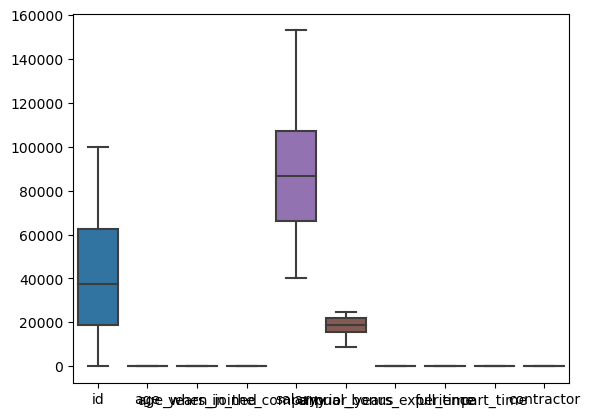

In [5]:
sns.boxplot(combined)

<Axes: >

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


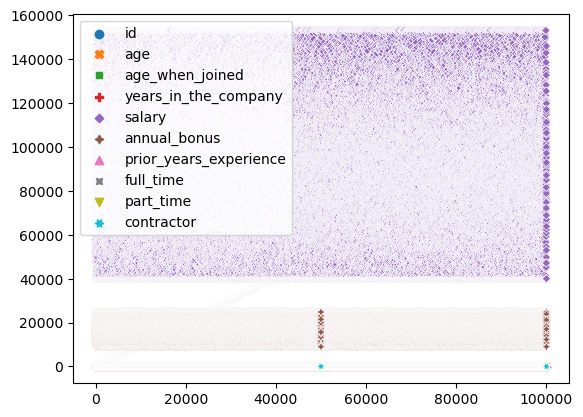

In [6]:
sns.scatterplot(combined)

<Axes: >

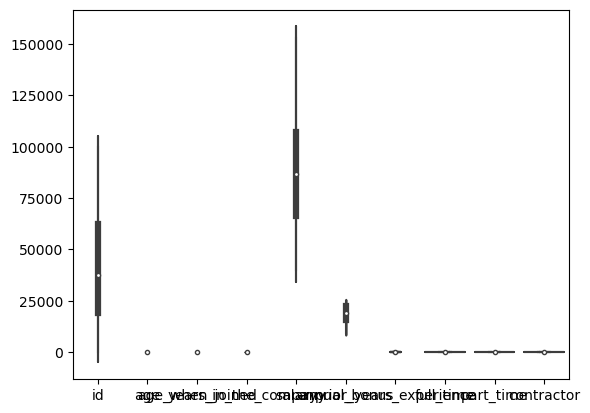

In [7]:
sns.violinplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


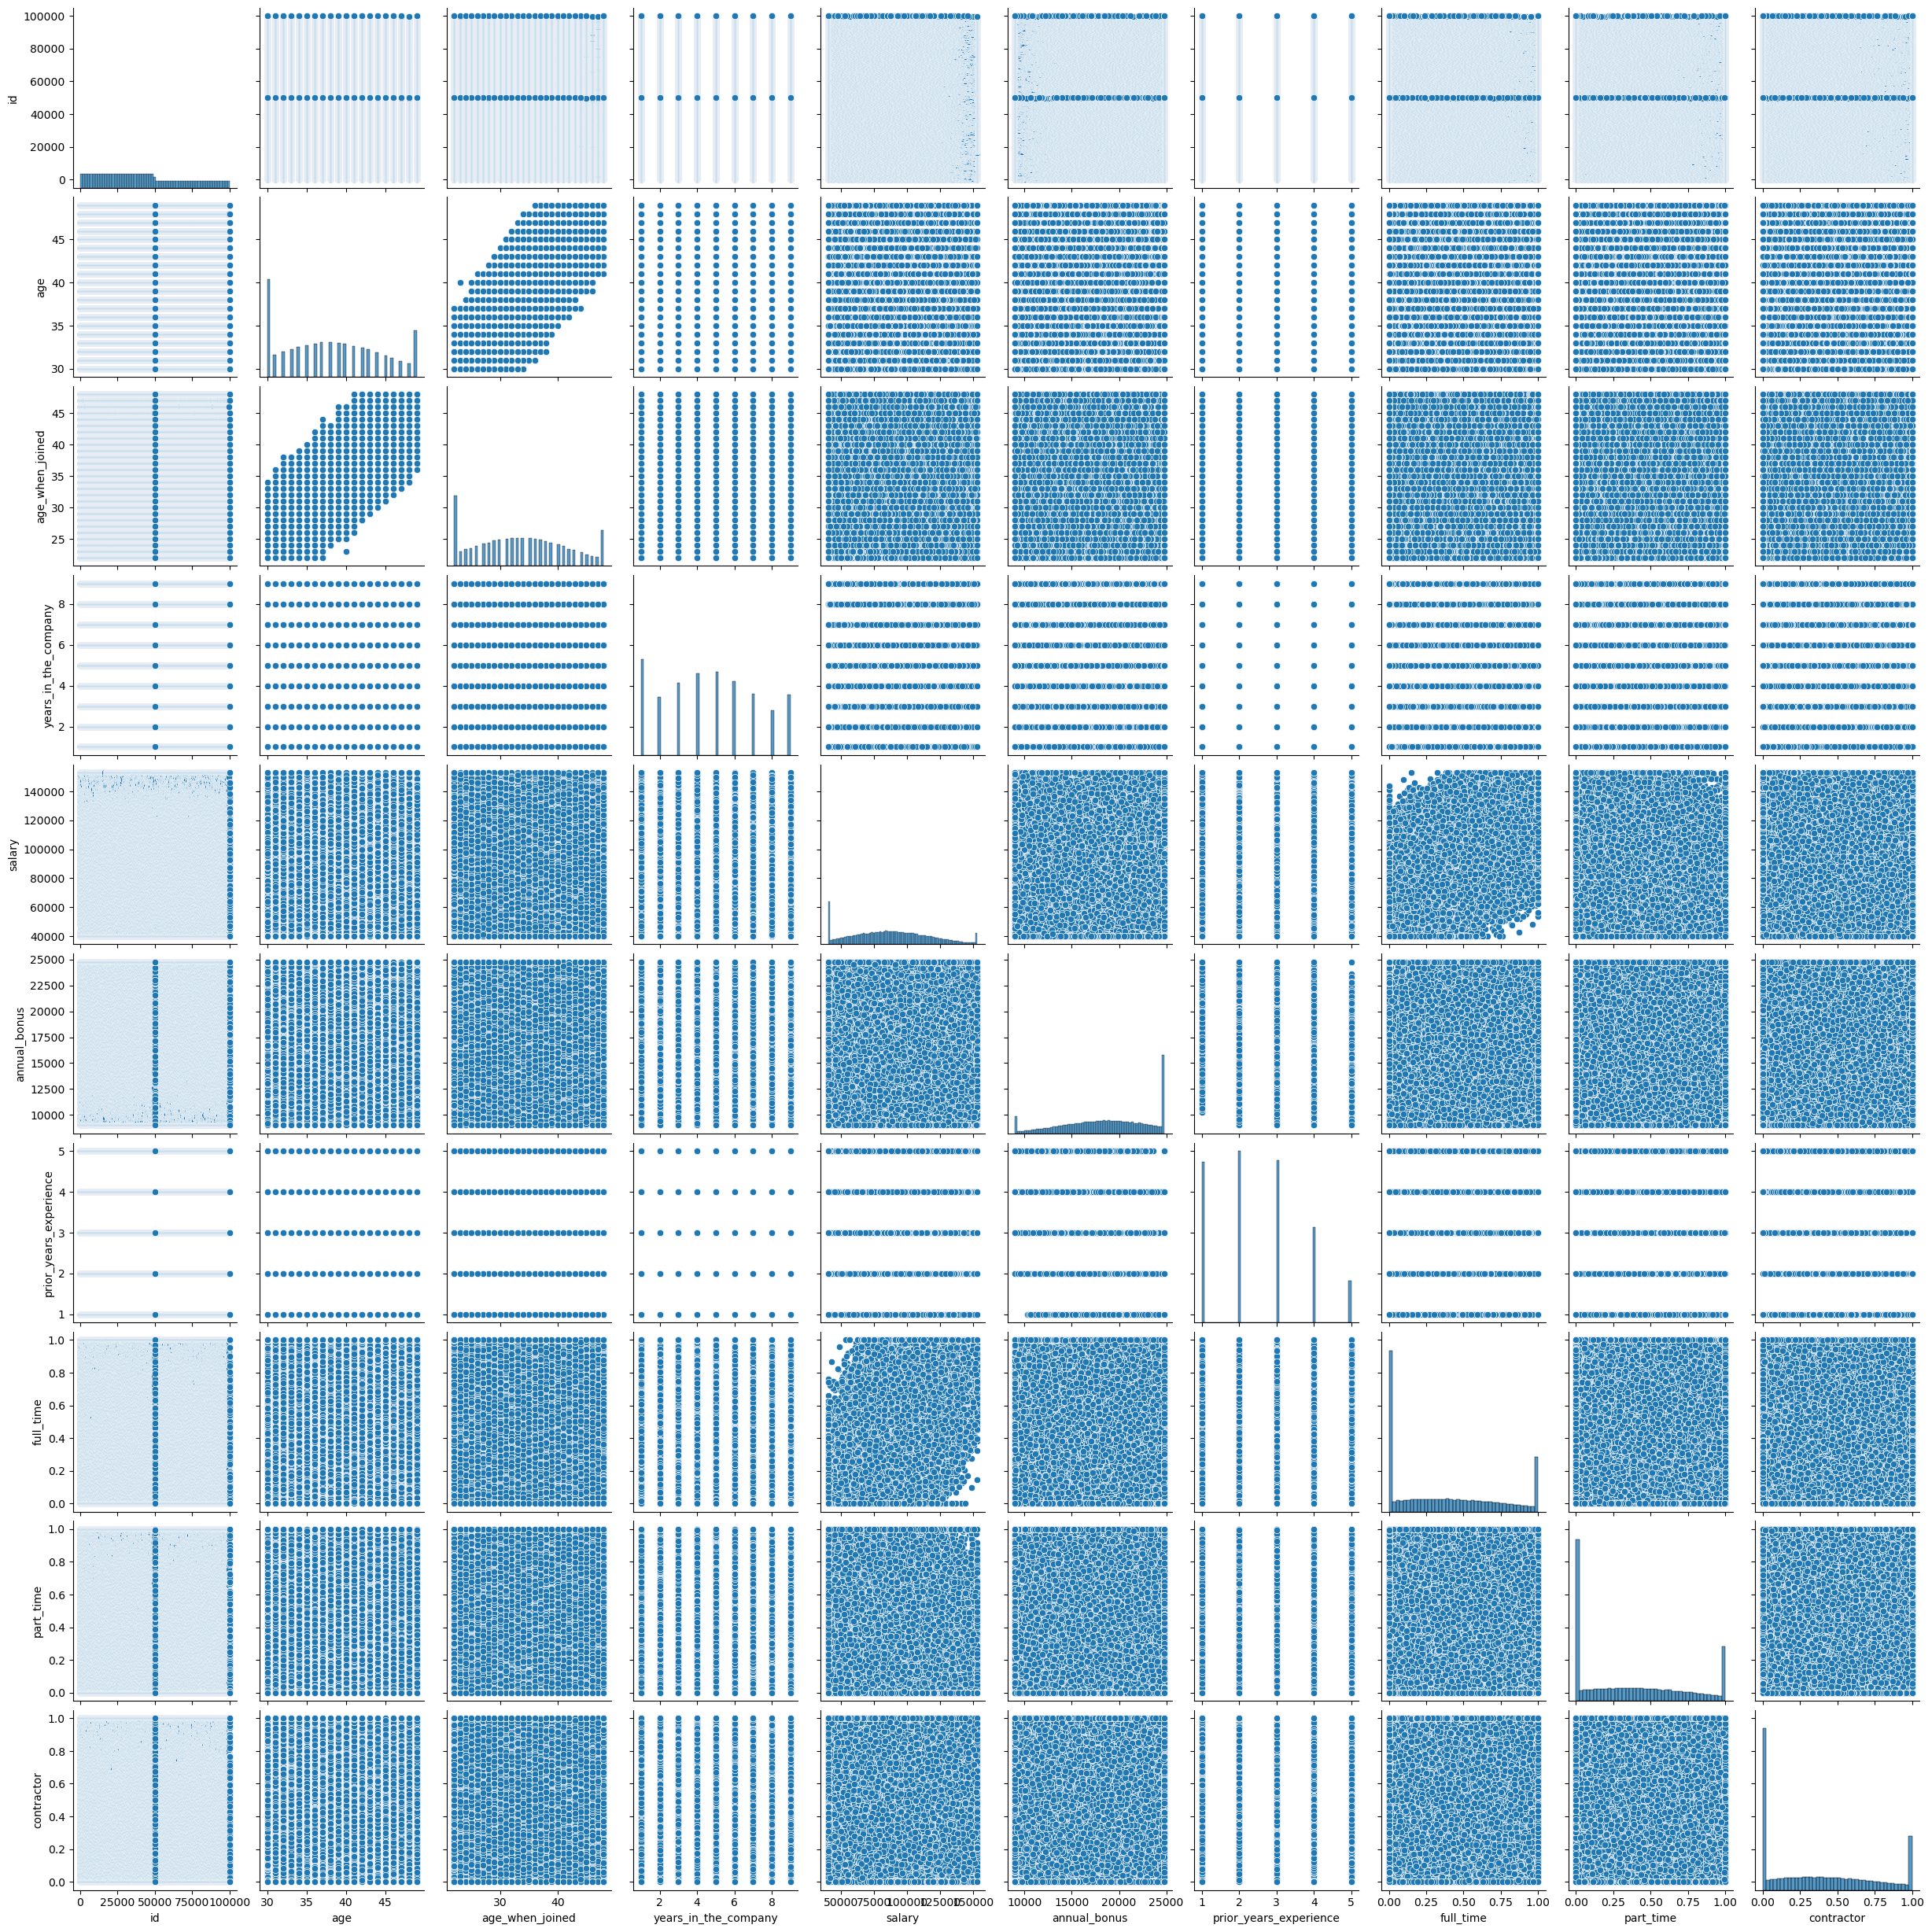

In [9]:
sns.pairplot(combined)

<Axes: >

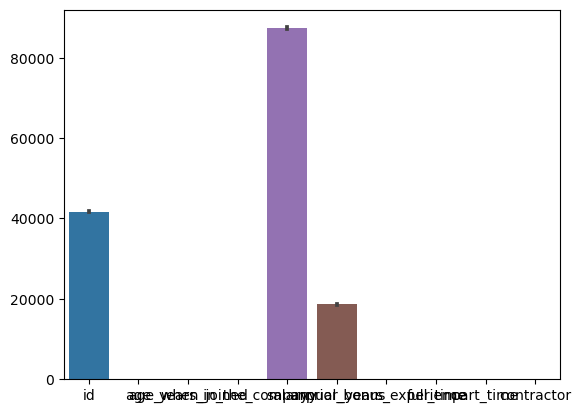

In [10]:
sns.barplot(combined)

/tmp/ipykernel_32/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

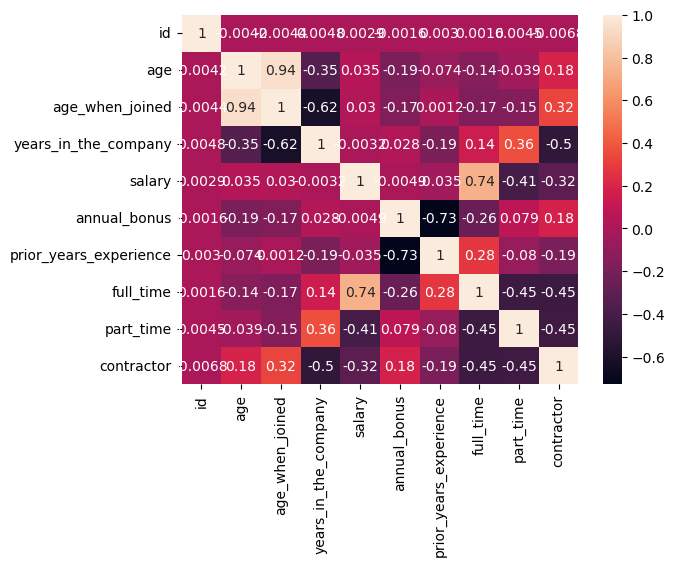

In [11]:
sns.heatmap(combined.corr(),annot=True)

In [9]:
cat_cols = combined.select_dtypes(include='object')

In [10]:
for i in cat_cols :
    print(i)
    combined[i].value_counts()
    print('_'*50)

company
__________________________________________________
department
__________________________________________________


In [11]:
num_cols = combined.select_dtypes(include='number')

In [12]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

id
1         2
33352     2
33330     2
33331     2
33332     2
         ..
66669     1
66670     1
66671     1
66672     1
100000    1
Name: id, Length: 100000, dtype: int64
__________________________________________________
age
30    23255
49    11116
37     8215
38     8197
39     8084
36     7887
40     7856
35     7537
41     7309
34     7033
42     6955
33     6582
43     6505
32     5946
44     5822
31     5279
45     5026
46     4471
47     3712
48     3213
Name: age, dtype: int64
__________________________________________________
age_when_joined
22    16745
48     8399
34     6711
33     6656
35     6654
32     6642
31     6515
36     6388
30     6288
37     6211
29     6137
38     5791
28     5582
39     5422
27     5262
40     5186
26     4776
41     4673
25     4267
42     4029
24     3922
43     3800
23     3416
44     3346
45     2779
46     2338
47     2065
Name: age_when_joined, dtype: int64
__________________________________________________
years_in_the_company
1    228

In [16]:
combined['id']=combined['id'].map({'Good':2,'Standard':1,'Poor':0})

/tmp/ipykernel_32/401063577.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


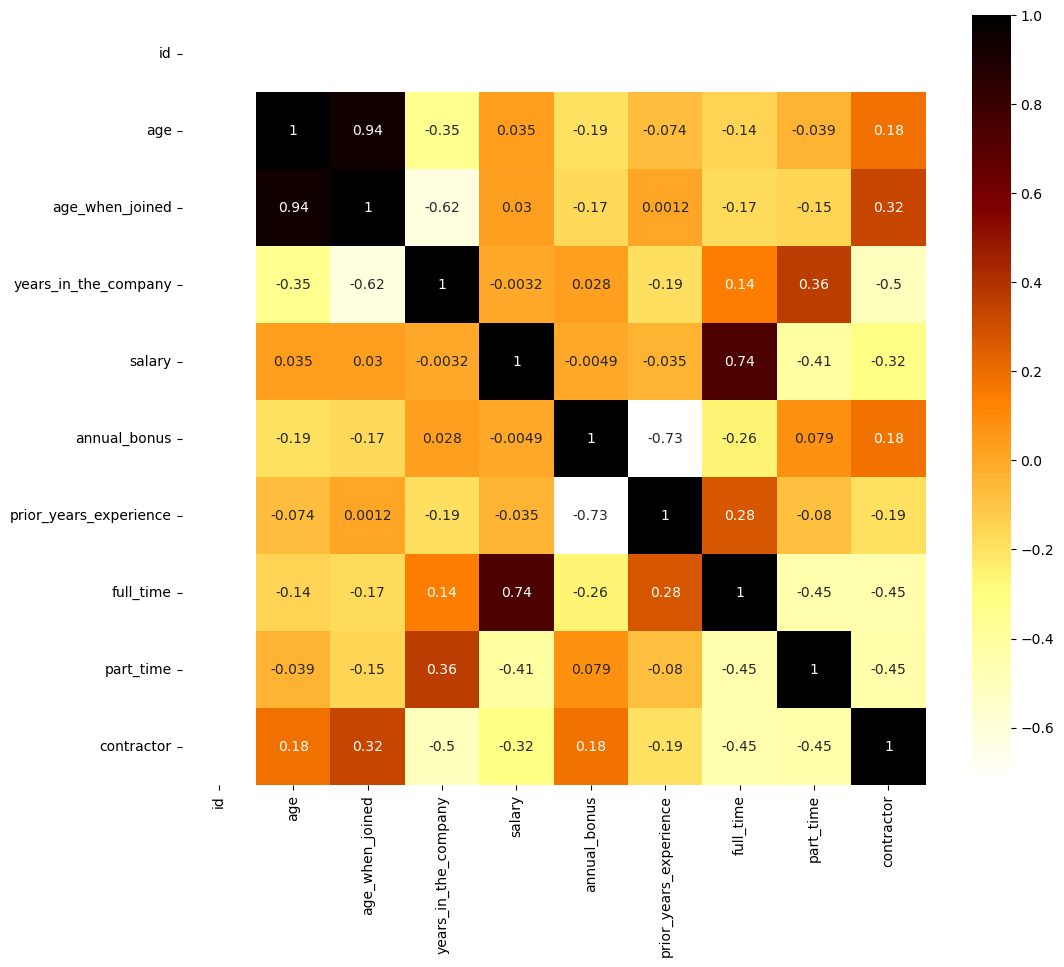

In [17]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

<Axes: ylabel='Density'>

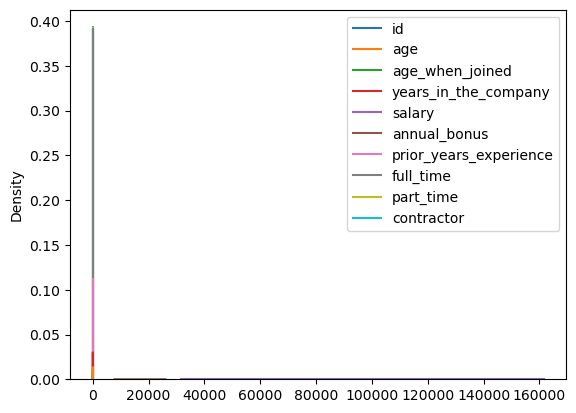

In [18]:
sns.kdeplot(combined)

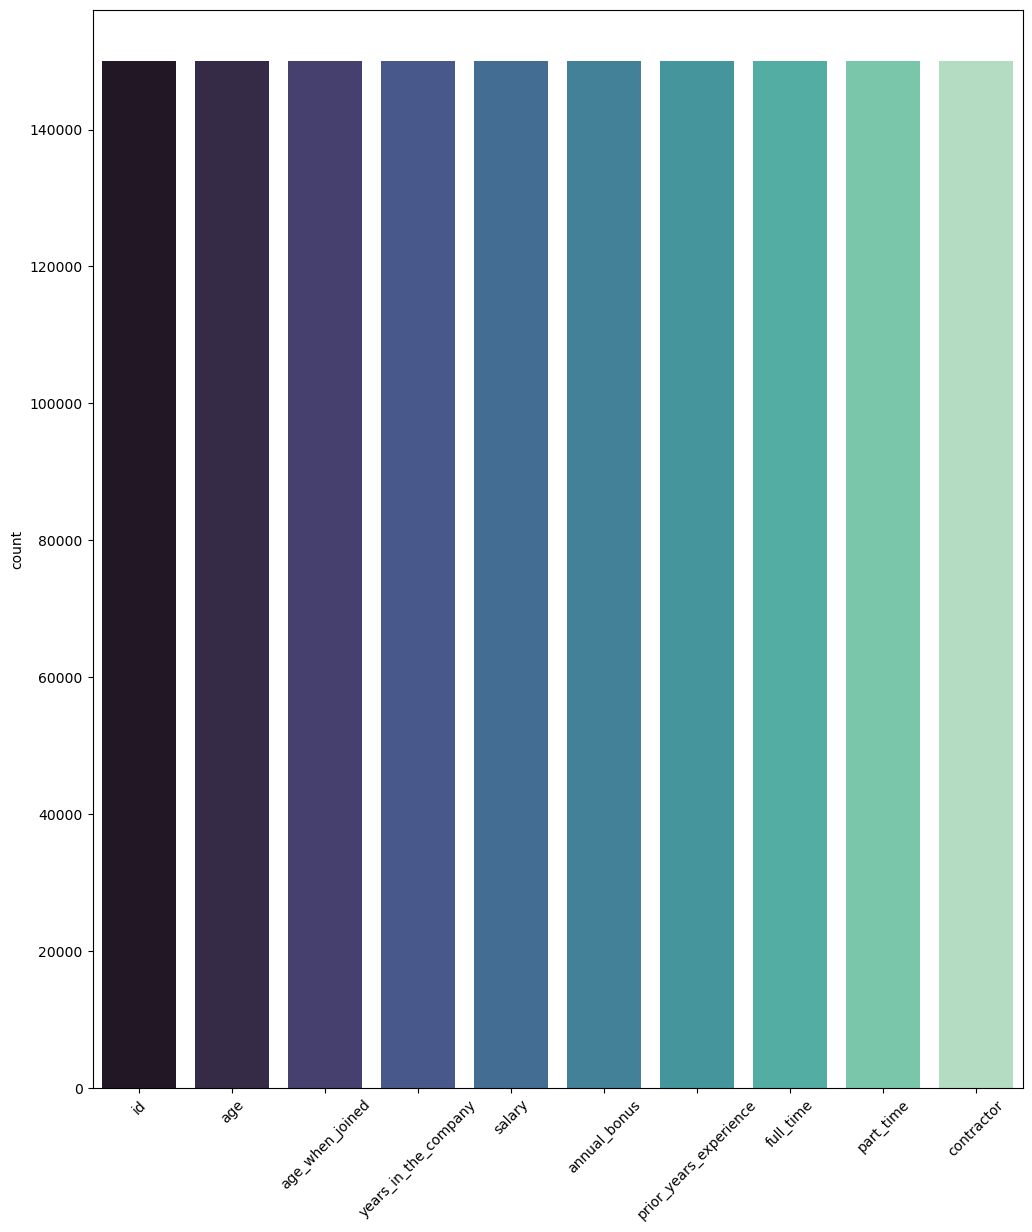

In [19]:
plt.figure(figsize=(12,14))
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=45);

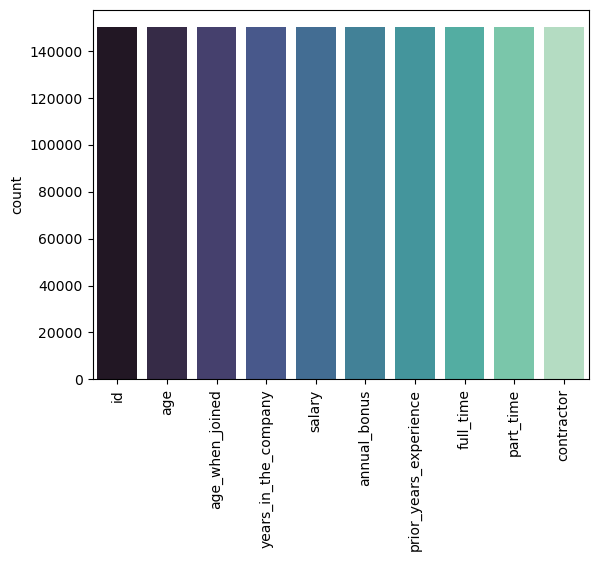

In [20]:
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=90);

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'id'),
  Text(1, 0, 'age'),
  Text(2, 0, 'age_when_joined'),
  Text(3, 0, 'years_in_the_company'),
  Text(4, 0, 'salary'),
  Text(5, 0, 'annual_bonus'),
  Text(6, 0, 'prior_years_experience'),
  Text(7, 0, 'full_time'),
  Text(8, 0, 'part_time'),
  Text(9, 0, 'contractor')])

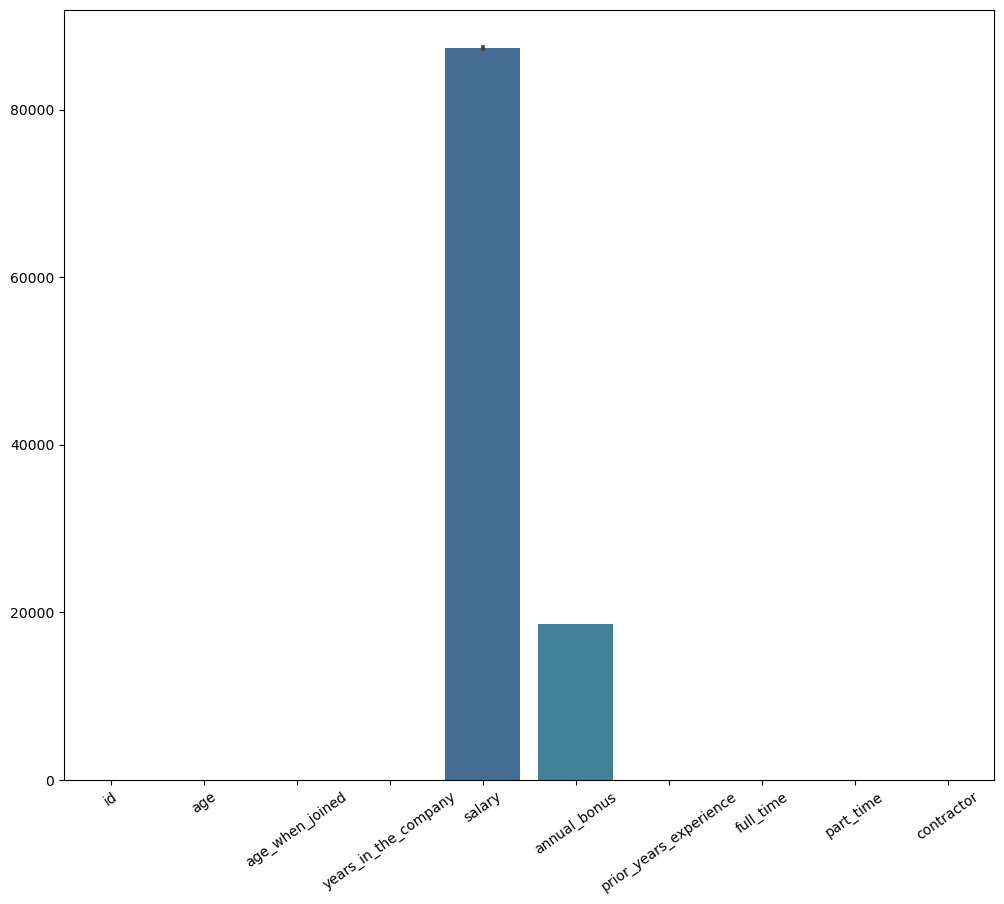

In [21]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako')
plt.xticks(rotation=35)

In [22]:
combined['id'].value_counts()

Series([], Name: id, dtype: int64)

In [23]:
combined['id'].unique()

array([nan])

company




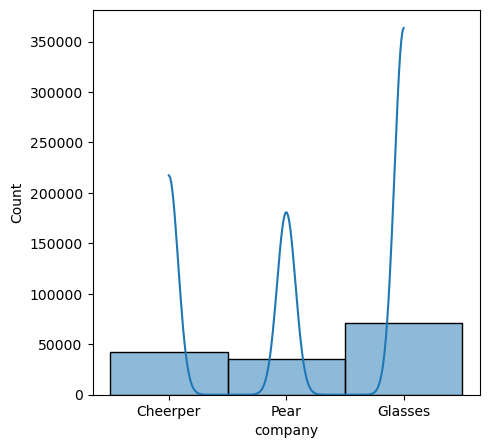

department




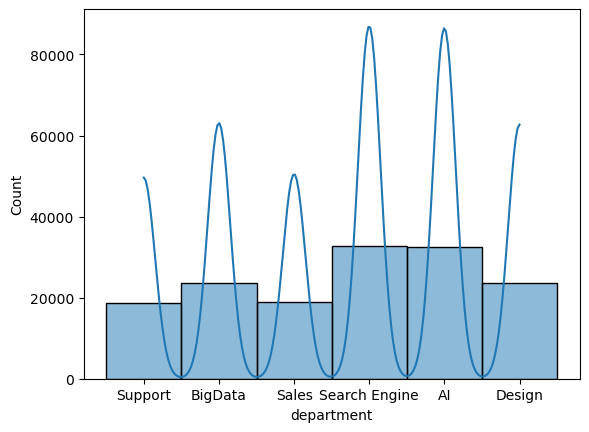

In [13]:
plt.figure(figsize=(5,5))
x=1
for i in cat_cols:
    print(i)
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()

id




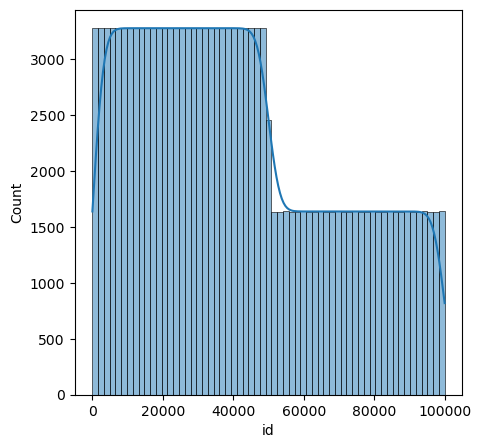

age




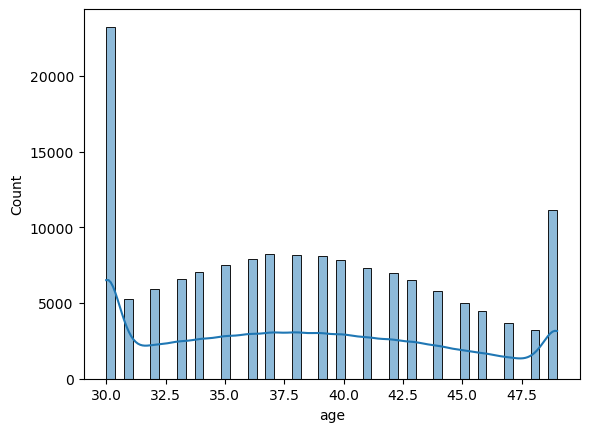

age_when_joined




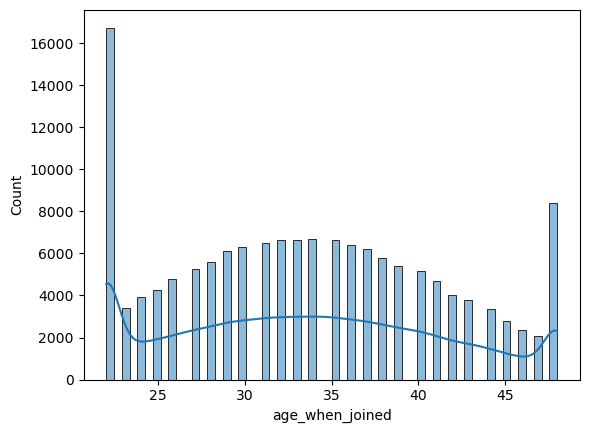

years_in_the_company




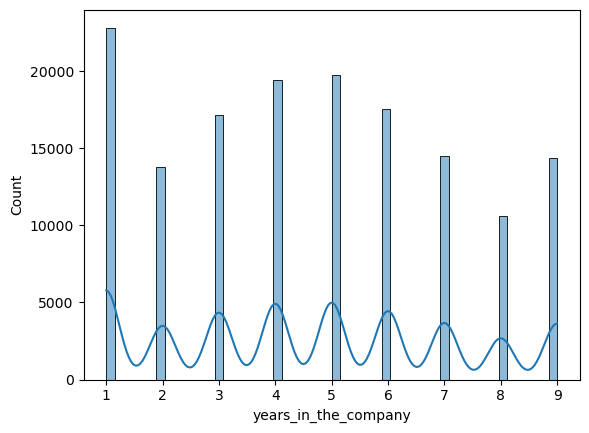

salary




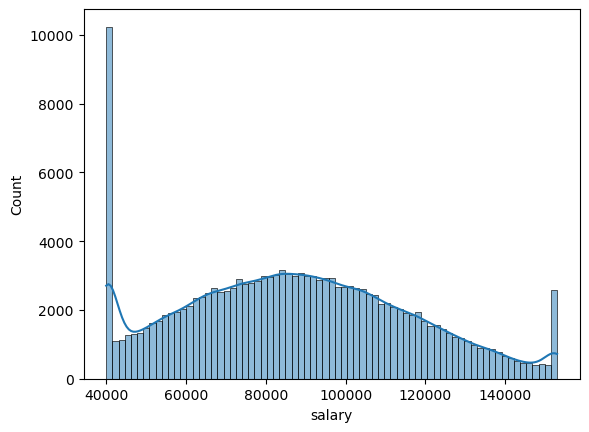

annual_bonus




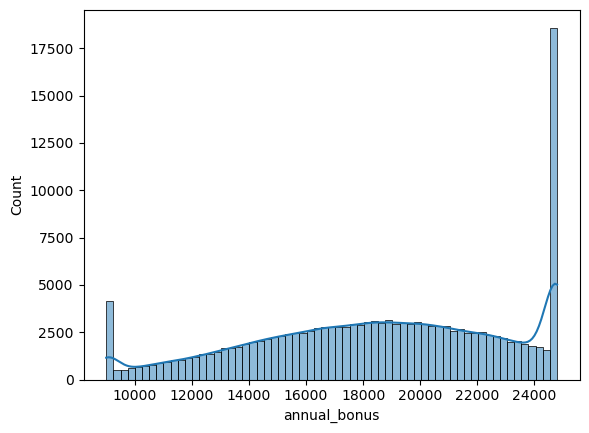

prior_years_experience




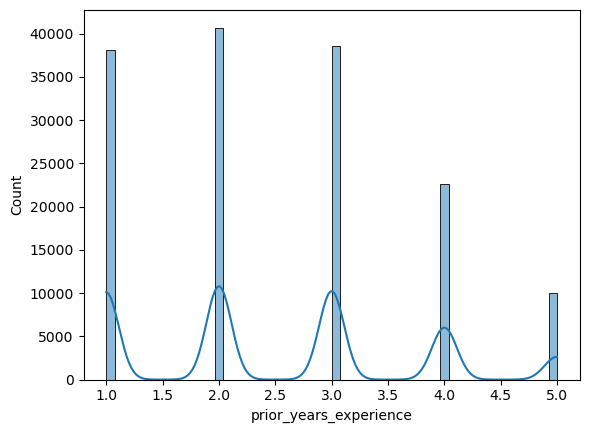

full_time




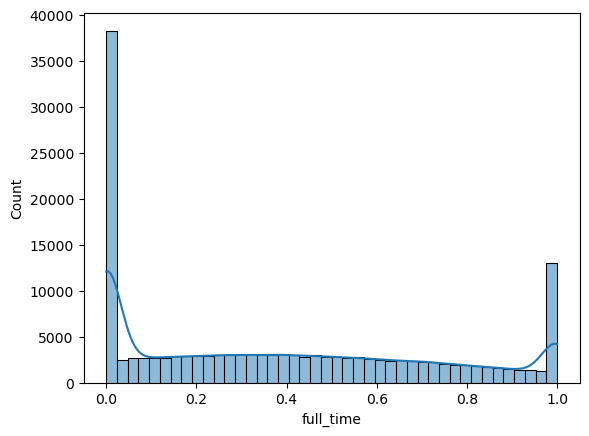

part_time




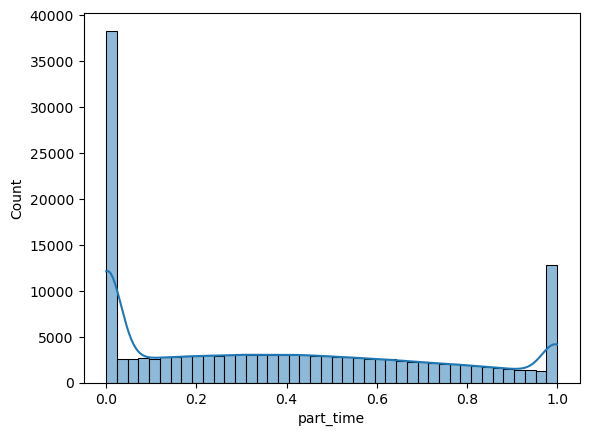

contractor




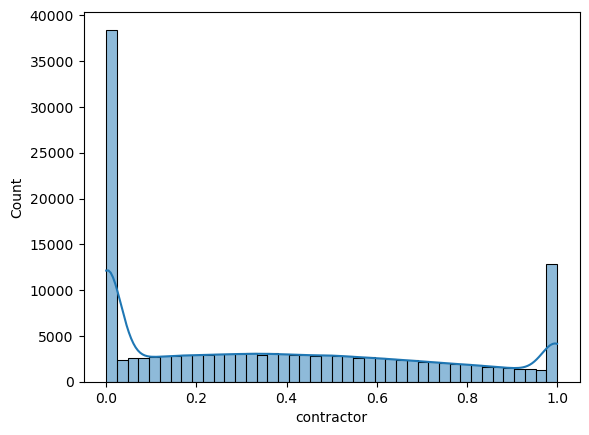

In [14]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    print(i)
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()